# Behavioural Scorecard & Stress Indicators
*Module B · Notebook 3 of 4 · AI Risk Decisioning System*

---

## Business Context

A raw probability (e.g. `delinquency_prob = 0.082`) is mathematically precise but operationally incomplete. A credit analyst, a collections officer, or a credit committee needs three additional things:

1. **A score on a familiar scale** — so they can benchmark against institutional policy ("approve if behavioural score > 650")
2. **Feature-level transparency** — so they can explain *why* a borrower has a high risk score
3. **Stress indicators** — flags that immediately surface the most dangerous patterns (e.g. escalating delinquency, critical utilisation) without requiring someone to interpret a raw probability

This notebook delivers all three:
- A **WoE-based behavioural scorecard** (0–100 scale) — analogous to Module A's 300–900 credit scorecard
- **Stress indicator flags** that the Decision Engine can act on directly
- A **score-to-risk mapping table** that documents the operational meaning of every score band

### Why a 0–100 Scale (Not 300–900)?

Module A uses the CIBIL-aligned 300–900 scale because it scores a borrower's full credit profile at origination. Module B measures **behavioural risk intensity** over a 2-year window — a different concept that intentionally uses a different scale to avoid confusion in the Decision Engine. The two scores are combined by the signal aggregator with explicit weights, not added together.

---

## Objectives

1. Compute **Weight of Evidence (WoE)** and **Information Value (IV)** for all behavioural features
2. Build a **0–100 behavioural scorecard** from WoE-transformed features
3. Define and compute **stress indicator flags** for the Decision Engine
4. Validate scorecard discrimination (AUC, KS)
5. Produce the **score-to-risk mapping table** for credit policy documentation
6. Save scorecard model and scored output

## Inputs
- `../01_data/processed/X_train_b.csv`
- `../01_data/processed/X_test_b.csv`
- `../01_data/processed/y_train_b.csv`
- `../01_data/processed/y_test_b.csv`
- `../01_data/processed/scored_test_b.csv`

## Outputs
- `../01_data/processed/scorecard_output_b.csv` — test set with behavioural scores + stress flags
- `../03_models/behavioural_scorecard.pkl` — WoE maps, points table, model


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import seaborn as sns
import warnings
import pickle
import os

from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import roc_auc_score, roc_curve

warnings.filterwarnings("ignore")
sns.set_style("whitegrid")
plt.rcParams["figure.dpi"] = 120

os.makedirs("../03_models", exist_ok=True)
print("Libraries loaded.")


Libraries loaded.


---
## 1. Load Data

In [2]:
X_train  = pd.read_csv("../01_data/processed/X_train_b.csv")
X_test   = pd.read_csv("../01_data/processed/X_test_b.csv")
y_train  = pd.read_csv("../01_data/processed/y_train_b.csv").squeeze()
y_test   = pd.read_csv("../01_data/processed/y_test_b.csv").squeeze()
scored_b = pd.read_csv("../01_data/processed/scored_test_b.csv")

print(f"Training set : {X_train.shape[0]:,} rows | {X_train.shape[1]} features")
print(f"\nAll features available:")
for f in X_train.columns:
    print(f"  {f}")


Training set : 119,784 rows | 18 features

All features available:
  RevolvingUtilizationOfUnsecuredLines
  age
  NumberOfTime30-59DaysPastDueNotWorse
  DebtRatio
  MonthlyIncome
  NumberOfOpenCreditLinesAndLoans
  NumberOfTimes90DaysLate
  NumberRealEstateLoansOrLines
  NumberOfTime60-89DaysPastDueNotWorse
  NumberOfDependents
  INCOME_MISSING
  DELINQUENCY_SCORE
  WORST_DELINQUENCY
  HAS_90DAY_LATE
  UTILIZATION_RISK_BAND
  DEBT_TO_INCOME
  INCOME_PER_DEPENDENT
  CREDIT_LINES_RISK


---
## 2. Weight of Evidence (WoE) & Information Value (IV)

### Methodology

WoE transforms each feature bin into a single number that represents the log-odds ratio between non-events (non-delinquent) and events (delinquent) within that bin:

$$WoE_i = \ln\left(\frac{\text{Distribution of Non-Events}_i}{\text{Distribution of Events}_i}\right)$$

$$IV = \sum_i (\text{Non-Events}_i\% - \text{Events}_i\%) \times WoE_i$$

**IV Selection Thresholds** (industry standard):

| IV | Predictive Power |
|----|-----------------|
| < 0.02 | Useless — drop |
| 0.02–0.10 | Weak |
| 0.10–0.30 | Medium |
| 0.30–0.50 | Strong |
| > 0.50 | Very strong (check for data leakage) |

Features with IV < 0.02 are excluded from the scorecard. We use 10 bins for continuous features and natural categories for discrete features.

In [3]:
def compute_woe_iv(X_col, y, n_bins=10, feature_name=""):
    """
    Compute WoE and IV for a single feature.
    Returns: (woe_map DataFrame, IV scalar)
    """
    df = pd.DataFrame({"x": X_col, "y": y}).copy()
    
    # Bin continuous features
    if df["x"].nunique() > 15:
        try:
            df["bin"] = pd.qcut(df["x"], q=n_bins, duplicates="drop")
        except Exception:
            df["bin"] = pd.cut(df["x"], bins=n_bins, duplicates="drop")
    else:
        df["bin"] = df["x"]

    total_events    = y.sum()
    total_nonevents = len(y) - total_events

    records = []
    for bin_val, grp in df.groupby("bin", observed=True):
        events    = grp["y"].sum()
        nonevents = len(grp) - events
        total     = len(grp)
        
        dist_events    = max(events, 0.5)    / total_events
        dist_nonevents = max(nonevents, 0.5) / total_nonevents
        
        woe = np.log(dist_nonevents / dist_events)
        iv  = (dist_nonevents - dist_events) * woe
        
        records.append({
            "bin"       : bin_val,
            "total"     : total,
            "events"    : int(events),
            "nonevents" : int(nonevents),
            "event_rate": events / total if total > 0 else 0,
            "WoE"       : woe,
            "IV"        : iv,
        })
    
    woe_df = pd.DataFrame(records).sort_values("bin")
    iv_total = woe_df["IV"].sum()
    return woe_df, iv_total


# ── Compute WoE/IV for all features ──────────────────────────────────────────
woe_maps = {}
iv_table = []
FEATURES = [c for c in X_train.columns]

for feat in FEATURES:
    woe_df, iv = compute_woe_iv(X_train[feat], y_train, n_bins=10, feature_name=feat)
    woe_maps[feat] = woe_df
    iv_table.append({"Feature": feat, "IV": round(iv, 4)})

iv_df = pd.DataFrame(iv_table).sort_values("IV", ascending=False)

print("INFORMATION VALUE TABLE")
print("=" * 60)
print(f"{'Feature':<45} {'IV':>8}  {'Power'}")
print("─" * 60)
for _, row in iv_df.iterrows():
    power = ("Very Strong" if row["IV"] > 0.50 else
             "Strong"      if row["IV"] > 0.30 else
             "Medium"      if row["IV"] > 0.10 else
             "Weak"        if row["IV"] > 0.02 else "Useless")
    flag = "✓" if row["IV"] >= 0.02 else "✗ (drop)"
    print(f"  {row['Feature']:<43} {row['IV']:>8.4f}  {power} {flag}")
print("=" * 60)

selected_features = iv_df[iv_df["IV"] >= 0.02]["Feature"].tolist()
print(f"\nFeatures selected (IV ≥ 0.02): {len(selected_features)}")
print(f"Features dropped              : {len(FEATURES) - len(selected_features)}")


INFORMATION VALUE TABLE
Feature                                             IV  Power
────────────────────────────────────────────────────────────
  WORST_DELINQUENCY                             1.3978  Very Strong ✓
  RevolvingUtilizationOfUnsecuredLines          1.1053  Very Strong ✓
  UTILIZATION_RISK_BAND                         1.0757  Very Strong ✓
  DELINQUENCY_SCORE                             1.0350  Very Strong ✓
  NumberOfTimes90DaysLate                       0.8544  Very Strong ✓
  HAS_90DAY_LATE                                0.8134  Very Strong ✓
  NumberOfTime30-59DaysPastDueNotWorse          0.7371  Very Strong ✓
  NumberOfTime60-89DaysPastDueNotWorse          0.5707  Very Strong ✓
  age                                           0.2518  Medium ✓
  INCOME_PER_DEPENDENT                          0.0933  Weak ✓
  DebtRatio                                     0.0835  Weak ✓
  MonthlyIncome                                 0.0634  Weak ✓
  NumberOfOpenCreditLinesAndLoans      

---
## 3. WoE Transformation

Each selected feature is replaced with its WoE value based on the bin it falls into. The scorecard logistic regression is then trained on WoE-transformed features — giving it a linear relationship between inputs and log-odds by construction.

In [4]:
def apply_woe_transform(X_df, woe_maps_dict, selected_feats):
    """
    Apply WoE transformation to a feature matrix.
    For each feature, replace raw values with WoE values from the bin mapping.
    """
    X_woe = pd.DataFrame(index=X_df.index)
    
    for feat in selected_feats:
        woe_df = woe_maps_dict[feat]
        x_vals = X_df[feat].copy()
        
        # Determine bin boundaries
        bins_list = woe_df["bin"].tolist()
        woe_vals = woe_df.set_index("bin")["WoE"].to_dict()
        
        # Map each value to its WoE
        if X_df[feat].nunique() > 15:
            # Continuous: find bin using the bin intervals from training
            try:
                labels = sorted(woe_vals.keys(),
                                key=lambda x: x.left if hasattr(x, "left") else x)

                bin_series = pd.cut(x_vals,
                                    bins=pd.IntervalIndex(labels),
                                    include_lowest=True)

                mapped = bin_series.map(woe_vals)

            except Exception:
                mapped = pd.Series(np.nan, index=x_vals.index)

        else:
            # Discrete: direct mapping
            mapped = x_vals.map(woe_vals)

        # Convert from categorical/object to numeric first
        mapped = pd.to_numeric(mapped.astype(object), errors="coerce")

        # Fill unseen values with neutral WoE
        X_woe[feat] = mapped.fillna(0.0)

    return X_woe


X_train_woe = apply_woe_transform(X_train, woe_maps, selected_features)
X_test_woe = apply_woe_transform(X_test, woe_maps, selected_features)

print("WoE transformation applied.")
print(f"Training WoE matrix: {X_train_woe.shape}")
print(f"Test WoE matrix    : {X_test_woe.shape}")

print("\nSample WoE values (first 3 rows, first 5 features):")
print(X_train_woe[selected_features[:5]].head(3).round(3).to_string())

WoE transformation applied.
Training WoE matrix: (119784, 16)
Test WoE matrix    : (29946, 16)

Sample WoE values (first 3 rows, first 5 features):
   WORST_DELINQUENCY  RevolvingUtilizationOfUnsecuredLines  UTILIZATION_RISK_BAND  DELINQUENCY_SCORE  NumberOfTimes90DaysLate
0              0.936                                 1.039                  1.246              0.553                    0.378
1              0.936                                 0.692                  0.429              0.553                    0.378
2              0.936                                -0.281                 -0.111              0.553                    0.378


---
## 4. Behavioural Scorecard — 0–100 Scale

The scorecard is built on WoE-transformed features with Logistic Regression. The log-odds output is linearly scaled to 0–100:

- **Score 0** = highest risk (delinquency probability approaching 100%)
- **Score 100** = lowest risk (delinquency probability approaching 0%)

Higher score = lower risk (consistent with how CIBIL and other bureau scores work).

In [5]:
# ── Train scorecard model on WoE features ────────────────────────────────────
scaler_woe = StandardScaler()
X_train_woe_scaled = scaler_woe.fit_transform(X_train_woe)
X_test_woe_scaled  = scaler_woe.transform(X_test_woe)

lr_scorecard = LogisticRegression(
    class_weight="balanced",
    max_iter=1000,
    random_state=42,
    C=1.0,
    solver="lbfgs"
)
lr_scorecard.fit(X_train_woe_scaled, y_train)

# ── Get log-odds for scoring ──────────────────────────────────────────────────
log_odds_train = lr_scorecard.decision_function(X_train_woe_scaled)
log_odds_test  = lr_scorecard.decision_function(X_test_woe_scaled)

# ── Scale to 0–100: higher score = lower risk ─────────────────────────────────
# Invert log-odds (higher log-odds = higher default risk = lower score)
lo_min = log_odds_train.min()
lo_max = log_odds_train.max()

def scale_to_score(log_odds, lo_min, lo_max):
    """Scale log-odds to 0–100. Higher score = lower risk (inverted)."""
    normalised = (log_odds - lo_min) / (lo_max - lo_min + 1e-9)
    return np.clip((1 - normalised) * 100, 0, 100).round(1)

train_scores = scale_to_score(log_odds_train, lo_min, lo_max)
test_scores  = scale_to_score(log_odds_test,  lo_min, lo_max)

scorecard_auc = roc_auc_score(y_test, -test_scores)  # negate: higher score = lower risk
print(f"Behavioural Scorecard AUC: {scorecard_auc:.4f}")
print(f"\nTest score distribution:")
print(f"  Mean   : {test_scores.mean():.1f}")
print(f"  Median : {np.median(test_scores):.1f}")
print(f"  Min    : {test_scores.min():.1f}")
print(f"  Max    : {test_scores.max():.1f}")
print(f"  Non-delinquent mean: {test_scores[y_test==0].mean():.1f}")
print(f"  Delinquent mean    : {test_scores[y_test==1].mean():.1f}")


Behavioural Scorecard AUC: 0.8515

Test score distribution:
  Mean   : 75.1
  Median : 79.6
  Min    : 3.4
  Max    : 99.6
  Non-delinquent mean: 76.9
  Delinquent mean    : 49.9


---
## 5. WoE Visualisation — Top Predictors

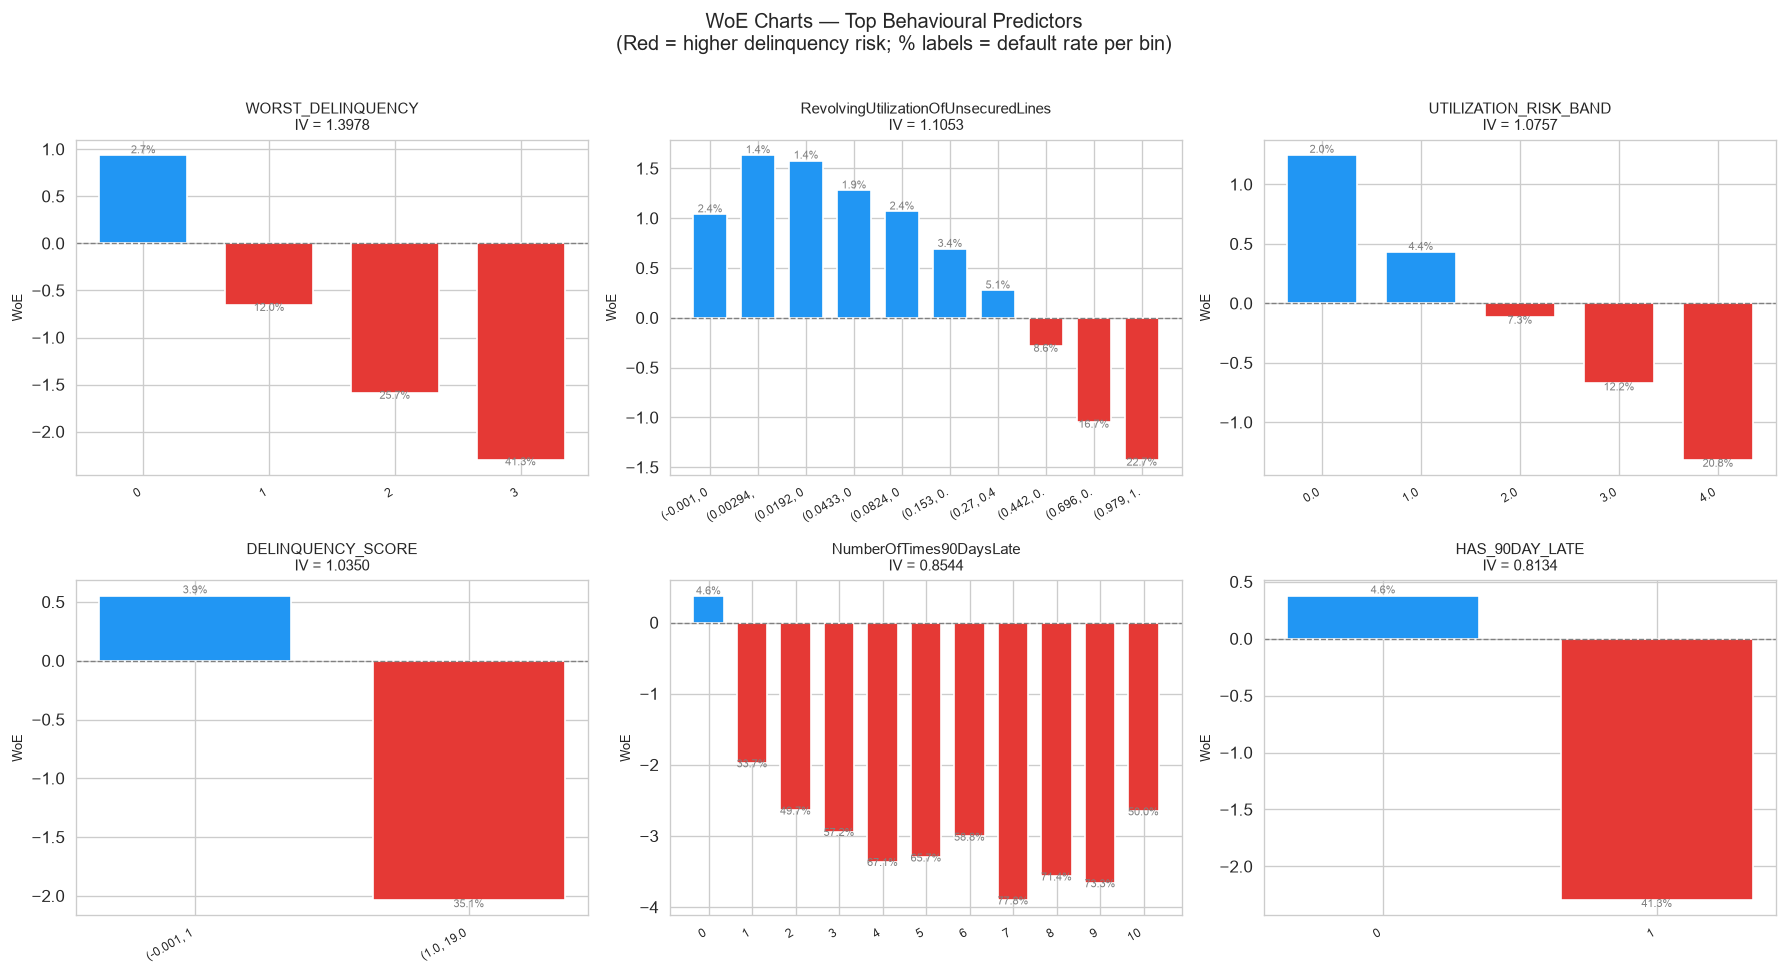

In [6]:
# Plot WoE charts for top 6 features by IV
top_feats_plot = iv_df[iv_df["IV"] >= 0.02]["Feature"].head(6).tolist()
n_plots = len(top_feats_plot)
ncols = 3
nrows = (n_plots + ncols - 1) // ncols

fig, axes = plt.subplots(nrows, ncols, figsize=(15, 4 * nrows))
axes = axes.flatten() if n_plots > 1 else [axes]

for i, feat in enumerate(top_feats_plot):
    ax = axes[i]
    woe_df = woe_maps[feat]
    iv_val = iv_df.loc[iv_df["Feature"]==feat, "IV"].values[0]
    
    x_pos  = range(len(woe_df))
    colors = ["#E53935" if w < 0 else "#2196F3" for w in woe_df["WoE"]]
    bars   = ax.bar(x_pos, woe_df["WoE"].values, color=colors, edgecolor="white", width=0.7)
    
    ax.axhline(0, color="gray", lw=0.8, linestyle="--")
    ax.set_xticks(list(x_pos))
    labels = [str(b)[:10] for b in woe_df["bin"]]
    ax.set_xticklabels(labels, rotation=30, ha="right", fontsize=7)
    ax.set_title(f"{feat}\nIV = {iv_val:.4f}", fontsize=9, pad=6)
    ax.set_ylabel("WoE", fontsize=8)
    
    # Add event rate as secondary label
    for j, (bar, er) in enumerate(zip(bars, woe_df["event_rate"])):
        ax.text(bar.get_x() + bar.get_width()/2,
                bar.get_height() + (0.02 if bar.get_height() >= 0 else -0.06),
                f"{er*100:.1f}%", ha="center", fontsize=6.5, color="gray")

# Hide unused plots
for ax in axes[n_plots:]:
    ax.set_visible(False)

plt.suptitle("WoE Charts — Top Behavioural Predictors\n(Red = higher delinquency risk; % labels = default rate per bin)",
             fontsize=12, y=1.01)
plt.tight_layout()
plt.show()


---
## 6. Score Distribution & Validation

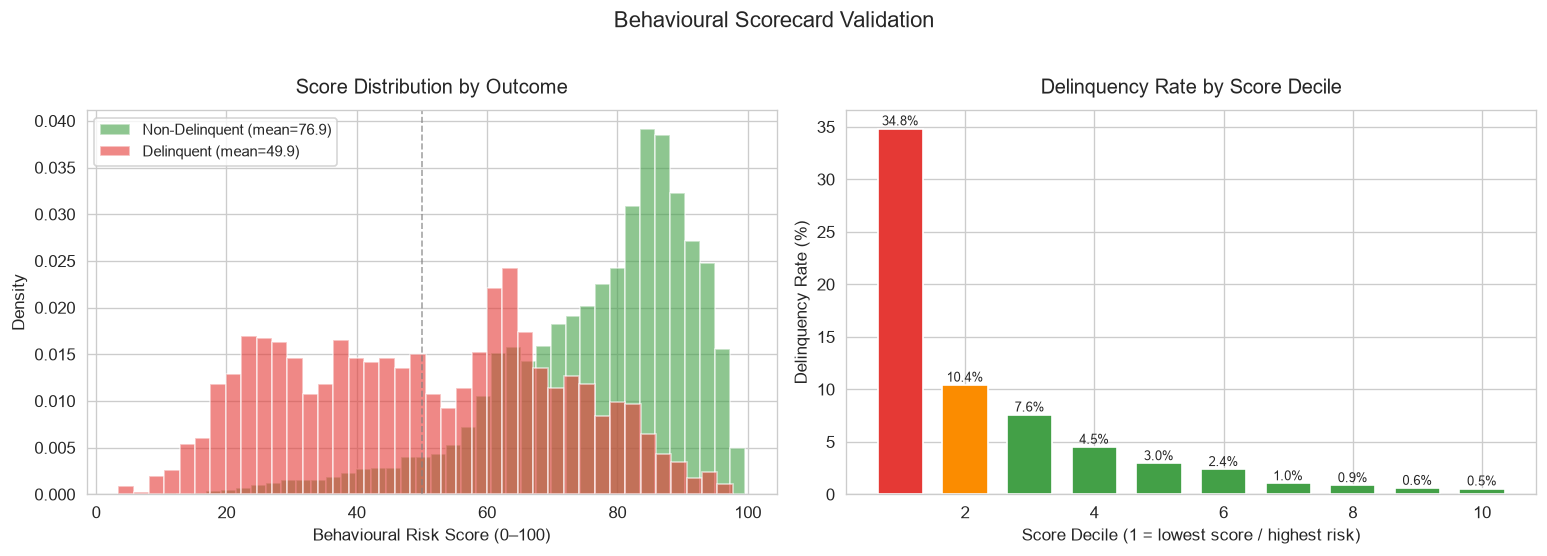


SCORECARD VALIDATION — PERFORMANCE vs BENCHMARK
                Model    AUC      Interpretable
   XGBoost (champion) 0.8571     No (black-box)
Behavioural Scorecard 0.8515 Yes (WoE additive)

AUC degradation vs XGBoost: 0.0056 — ACCEPTABLE


In [7]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

# Score distributions by outcome
axes[0].hist(test_scores[y_test==0], bins=40, alpha=0.6, color="#43A047",
             label=f"Non-Delinquent (mean={test_scores[y_test==0].mean():.1f})", density=True)
axes[0].hist(test_scores[y_test==1], bins=40, alpha=0.6, color="#E53935",
             label=f"Delinquent (mean={test_scores[y_test==1].mean():.1f})",     density=True)
axes[0].axvline(50, color="gray", linestyle="--", lw=1, alpha=0.7)
axes[0].set_xlabel("Behavioural Risk Score (0–100)")
axes[0].set_ylabel("Density")
axes[0].set_title("Score Distribution by Outcome", fontsize=12, pad=10)
axes[0].legend(fontsize=9)

# Default rate by score decile
score_df = pd.DataFrame({"score": test_scores, "delinquent": y_test.values})
score_df["decile"] = pd.qcut(score_df["score"], q=10, labels=False, duplicates="drop") + 1
decile_dr = score_df.groupby("decile")["delinquent"].mean() * 100

colors_d = ["#E53935" if dr > 15 else "#FB8C00" if dr > 8 else "#43A047"
            for dr in decile_dr.values]
axes[1].bar(decile_dr.index, decile_dr.values, color=colors_d, edgecolor="white", width=0.7)
for i, dr in zip(decile_dr.index, decile_dr.values):
    axes[1].text(i, dr + 0.3, f"{dr:.1f}%", ha="center", fontsize=8)
axes[1].set_xlabel("Score Decile (1 = lowest score / highest risk)")
axes[1].set_ylabel("Delinquency Rate (%)")
axes[1].set_title("Delinquency Rate by Score Decile", fontsize=12, pad=10)

plt.suptitle("Behavioural Scorecard Validation", fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

# AUC comparison
from sklearn.metrics import roc_auc_score
from xgboost import XGBClassifier
import pickle

xgb_loaded = pickle.load(open("../03_models/xgb_behavioural.pkl", "rb"))
xgb_preds  = xgb_loaded.predict_proba(X_test)[:, 1]
xgb_auc    = roc_auc_score(y_test, xgb_preds)

comparison = pd.DataFrame({
    "Model"          : ["XGBoost (champion)", "Behavioural Scorecard"],
    "AUC"            : [round(xgb_auc, 4), round(scorecard_auc, 4)],
    "Interpretable"  : ["No (black-box)", "Yes (WoE additive)"]
})
print("\nSCORECARD VALIDATION — PERFORMANCE vs BENCHMARK")
print("=" * 55)
print(comparison.to_string(index=False))
print("=" * 55)
deg = xgb_auc - scorecard_auc
print(f"\nAUC degradation vs XGBoost: {deg:.4f} — {'ACCEPTABLE' if deg <= 0.03 else 'REVIEW BINNING'}")


---
## 7. Score-to-Risk Mapping Table

The operational document for credit policy. Maps any behavioural score to a risk grade, expected delinquency probability, and recommended Decision Engine action.

In [8]:
SCORE_BANDS_B = [
    (80, 100, "Very Low Risk",  "< 3%",    "No adverse action"),
    (60,  79, "Low Risk",       "3–7%",    "No adverse action"),
    (40,  59, "Moderate Risk",  "7–15%",   "Flag for monitoring"),
    (20,  39, "High Risk",      "15–30%",  "Escalate to manual review"),
    (0,   19, "Critical Risk",  "> 30%",   "Override — decline recommended"),
]

score_df2 = pd.DataFrame({"score": test_scores, "delinquent": y_test.values})
mapping_records = []
for lo, hi, grade, expected_pd, action in SCORE_BANDS_B:
    mask = (score_df2["score"] >= lo) & (score_df2["score"] <= hi)
    n     = mask.sum()
    dr    = score_df2.loc[mask, "delinquent"].mean() * 100 if n > 0 else 0
    mapping_records.append({
        "Score Range": f"{lo}–{hi}",
        "Risk Grade" : grade,
        "Expected PD": expected_pd,
        "Actual Delinq Rate": f"{dr:.1f}%",
        "Borrowers (Test)": f"{n:,}",
        "Decision Engine Action": action
    })

mapping_table = pd.DataFrame(mapping_records)
print("BEHAVIOURAL SCORE-TO-RISK MAPPING TABLE")
print("=" * 95)
print(mapping_table.to_string(index=False))
print("=" * 95)


BEHAVIOURAL SCORE-TO-RISK MAPPING TABLE
Score Range    Risk Grade Expected PD Actual Delinq Rate Borrowers (Test)         Decision Engine Action
     80–100 Very Low Risk        < 3%               1.1%           14,737              No adverse action
      60–79      Low Risk        3–7%               5.8%            9,911              No adverse action
      40–59 Moderate Risk       7–15%              17.0%            2,834            Flag for monitoring
      20–39     High Risk      15–30%              43.2%            1,280      Escalate to manual review
       0–19 Critical Risk       > 30%              68.7%              163 Override — decline recommended


---
## 8. Stress Indicator Flags

Stress flags are binary indicators of the **most dangerous behavioural patterns**. They bypass the scorecard and go directly to the Decision Engine as hard signals — the equivalent of a "red flag" a human credit analyst would immediately act on.

| Flag | Condition | Interpretation |
|------|-----------|----------------|
| `STRESS_FLAG` | Has 90DPD history OR delinquency score ≥ 3 | General financial distress signal |
| `CRITICAL_UTILISATION` | Revolving utilisation ≥ 80% | Credit card maxed — immediate liquidity concern |
| `ESCALATING_DELINQUENCY` | 60/90DPD events exist (not just 30DPD) | Pattern is worsening, not stable |
| `HIGH_DELINQUENCY_SCORE` | Delinquency score ≥ 5 | Severe, repeated delinquency history |

In [9]:
# Load the scored file to add stress flags
scored_final = pd.read_csv("../01_data/processed/scored_test_b.csv")

# ── STRESS_FLAG (already in scored file, but recompute for clarity) ────────────
scored_final["STRESS_FLAG"] = (
    (scored_final.get("HAS_90DAY_LATE", 0) == 1) |
    (scored_final.get("DELINQUENCY_SCORE", 0) >= 3)
).astype(int)

# ── CRITICAL_UTILISATION ──────────────────────────────────────────────────────
if "RevolvingUtilizationOfUnsecuredLines" in scored_final.columns:
    scored_final["CRITICAL_UTILISATION"] = (
        scored_final["RevolvingUtilizationOfUnsecuredLines"] >= 0.80
    ).astype(int)

# ── ESCALATING_DELINQUENCY ────────────────────────────────────────────────────
if "NumberOfTimes90DaysLate" in scored_final.columns and    "NumberOfTime60-89DaysPastDueNotWorse" in scored_final.columns:
    scored_final["ESCALATING_DELINQUENCY"] = (
        (scored_final["NumberOfTimes90DaysLate"] > 0) |
        (scored_final["NumberOfTime60-89DaysPastDueNotWorse"] > 0)
    ).astype(int)

# ── HIGH_DELINQUENCY_SCORE ────────────────────────────────────────────────────
if "DELINQUENCY_SCORE" in scored_final.columns:
    scored_final["HIGH_DELINQUENCY_SCORE"] = (
        scored_final["DELINQUENCY_SCORE"] >= 5
    ).astype(int)

# ── Validate flags against actual delinquency ─────────────────────────────────
flag_cols = ["STRESS_FLAG", "CRITICAL_UTILISATION", "ESCALATING_DELINQUENCY", "HIGH_DELINQUENCY_SCORE"]
flag_cols = [f for f in flag_cols if f in scored_final.columns]

print("STRESS FLAG VALIDATION")
print("=" * 75)
print(f"{'Flag':<30} {'Flagged':>8}  {'% Port':>8}  {'Delinq (flag=1)':>16}  {'Delinq (flag=0)':>16}")
print("─" * 75)
for flag in flag_cols:
    n_flag     = scored_final[flag].sum()
    pct_port   = n_flag / len(scored_final) * 100
    dr_flagged = scored_final.loc[scored_final[flag]==1, "ACTUAL_DELINQUENCY"].mean() * 100
    dr_clean   = scored_final.loc[scored_final[flag]==0, "ACTUAL_DELINQUENCY"].mean() * 100
    print(f"  {flag:<28} {n_flag:>8,}  {pct_port:>7.1f}%  {dr_flagged:>15.1f}%  {dr_clean:>15.1f}%")
print("=" * 75)


STRESS FLAG VALIDATION
Flag                            Flagged    % Port   Delinq (flag=1)   Delinq (flag=0)
───────────────────────────────────────────────────────────────────────────
  STRESS_FLAG                     2,154      7.2%             38.4%              4.1%
  CRITICAL_UTILISATION            4,907     16.4%             20.3%              3.9%
  ESCALATING_DELINQUENCY          2,537      8.5%             34.9%              4.0%
  HIGH_DELINQUENCY_SCORE            468      1.6%             58.3%              5.8%


---
## 9. Save Final Scored Output and Scorecard Model

In [10]:
# Add scorecard score and band to scored output
scored_final["BEHAVIOURAL_SCORE"]     = test_scores
scored_final["BEHAVIOURAL_SCORE_BAND"] = pd.cut(
    scored_final["BEHAVIOURAL_SCORE"],
    bins=[-1, 20, 40, 60, 80, 101],
    labels=["Critical Risk", "High Risk", "Moderate Risk", "Low Risk", "Very Low Risk"]
)

scored_final.to_csv("../01_data/processed/scorecard_output_b.csv", index=False)
print(f"Scorecard output saved: {scored_final.shape[0]:,} rows")
print(f"New columns: BEHAVIOURAL_SCORE, BEHAVIOURAL_SCORE_BAND + stress flags")

# ── Save scorecard model ──────────────────────────────────────────────────────
scorecard_pkg = {
    "lr_model"          : lr_scorecard,
    "scaler"            : scaler_woe,
    "woe_maps"          : woe_maps,
    "selected_features" : selected_features,
    "iv_table"          : iv_df,
    "mapping_table"     : mapping_table,
    "lo_min"            : lo_min,
    "lo_max"            : lo_max,
}
with open("../03_models/behavioural_scorecard.pkl", "wb") as f:
    pickle.dump(scorecard_pkg, f)

print("\nBehavioural scorecard saved: ../03_models/behavioural_scorecard.pkl")


Scorecard output saved: 29,946 rows
New columns: BEHAVIOURAL_SCORE, BEHAVIOURAL_SCORE_BAND + stress flags

Behavioural scorecard saved: ../03_models/behavioural_scorecard.pkl


---
## 10. Module B Signal — Complete Output Schema

```python
# Complete Module B signal — ready for Decision Engine (Module D)
{
  # From NB02 (Delinquency Model)
  "delinquency_prob":        float,  # 0.0–1.0   P(90DPD in 2yr) — XGBoost
  "behavioural_risk_score":  float,  # 0–100     Scaled from delinquency_prob
  "behavioural_risk_band":   int,    # 1–5       (1=Very Low, 5=Very High)
  "utilisation_risk":        str,    # "Low"/"Medium"/"High"/"Critical"
  
  # From NB03 (Scorecard)
  "behavioural_score":       float,  # 0–100     WoE scorecard (higher = safer)
  "behavioural_score_band":  str,    # "Very Low Risk" to "Critical Risk"
  
  # Stress flags
  "stress_flag":             bool,   # Has 90DPD OR delinquency_score ≥ 3
  "critical_utilisation":    bool,   # Revolving utilisation ≥ 80%
  "escalating_delinquency":  bool,   # Has 60DPD or 90DPD events
  "high_delinquency_score":  bool,   # Delinquency score ≥ 5 (repeated pattern)
}
```

### Decision Engine Integration

The Decision Engine (Module D) will combine this signal with Module A using configurable weights:

```
Composite Risk Score = w_A × (Module A PD) + w_B × (Module B delinquency_prob)
                     Default weights: w_A = 0.60, w_B = 0.40
```

Stress flags are treated as **hard overrides** — if `high_delinquency_score = True`, the engine routes to Manual Review regardless of the composite score.

### Next Step

`04_shap_explainability.ipynb` adds SHAP-based feature attribution — so every decision produced by the Decision Engine can be explained at the feature level with a ranked list of "why this borrower was flagged."
